# 📊 Police Shootings Data Analysis (USA)

This project analyzes police shooting data along with U.S. Census data to explore trends and relationships with socio-economic factors.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Data Loading

Loading the police shootings dataset and census dataset for analysis.

In [5]:
df_police = pd.read_csv("Deaths_by_Police_US.csv", encoding="latin-1")

df_income = pd.read_csv("Median_Household_Income_2015.csv", encoding="latin-1")
df_education = pd.read_csv("Pct_Over_25_Completed_High_School.csv", encoding="latin-1")
df_poverty = pd.read_csv("Pct_People_Below_Poverty_Level.csv", encoding="latin-1")
df_race = pd.read_csv("Share_of_Race_By_City.csv", encoding="latin-1")

df_police.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.0,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.0,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.0,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.0,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.0,M,H,Evans,CO,False,attack,Not fleeing,False


## 🧹 Cleaning Column Names

Standardizing column names for easier merging.

In [6]:
df_police.columns = df_police.columns.str.lower()
df_income.columns = df_income.columns.str.lower()
df_poverty.columns = df_poverty.columns.str.lower()
df_race.columns = df_race.columns.str.lower()


## 🔗 Merging Datasets

Combining police data with socio-economic data for deeper analysis.

In [7]:
df_merged = df_police.merge(df_income, on="city")
df_merged = df_merged.merge(df_poverty,on="city")
df_merged = df_merged.merge(df_race,on="city")
df_merged.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,...,geographic area_x,median income,geographic area_y,poverty_rate,geographic area,share_white,share_black,share_native_american,share_asian,share_hispanic
0,744,Jonathon Pope,15/08/15,shot,gun,30.0,M,W,Carson City,NV,...,NV,47668,NV,16.8,NV,81.1,1.9,2.4,2.1,21.3
1,2008,Henry Simpson,01/11/16,shot,gun,76.0,M,W,Carson City,NV,...,NV,47668,NV,16.8,NV,81.1,1.9,2.4,2.1,21.3


## 📊 Deaths Over Time

Analyzing yearly trends in police-related deaths.

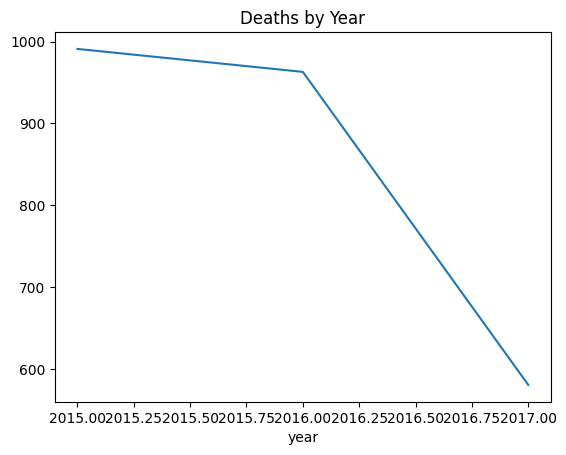

In [9]:
df_police['date'] = pd.to_datetime(df_police['date'])
df_police['year'] = df_police['date'].dt.year

df_police['year'].value_counts().plot()
plt.title("Deaths by Year")
plt.show()

## 🧑‍🤝‍🧑 Deaths by Race

Understanding racial distribution of fatalities.

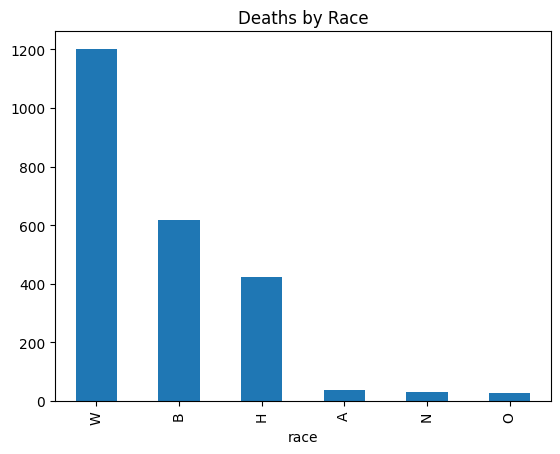

In [10]:
df_police['race'].value_counts().plot(kind='bar')
plt.title("Deaths by Race")
plt.show()

## 📉 Poverty vs Deaths

Exploring relationship between poverty and police deaths.

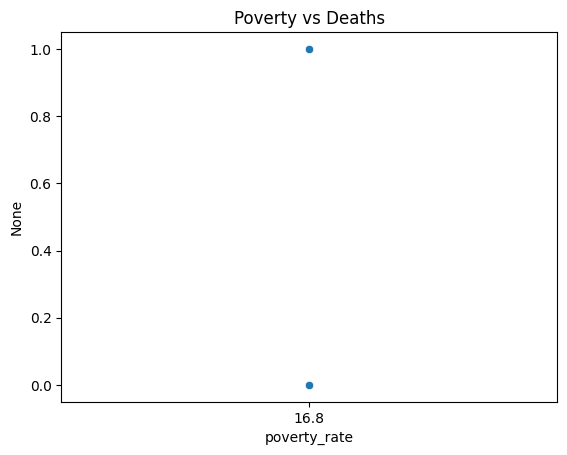

In [11]:
import seaborn as sns

sns.scatterplot(x=df_merged['poverty_rate'], y=df_merged.index)
plt.title("Poverty vs Deaths")
plt.show()

## 💰 Income vs Deaths

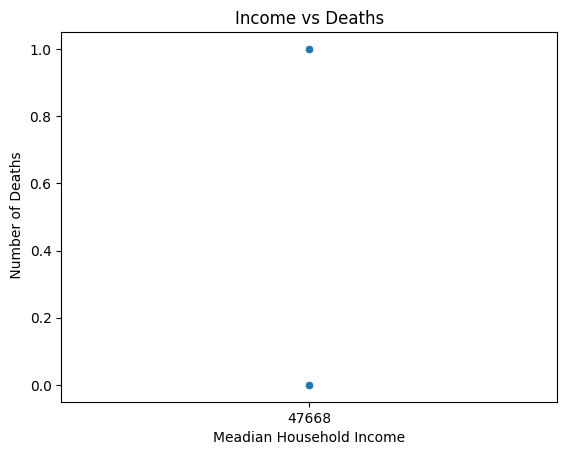

In [18]:
sns.scatterplot(x=df_merged['median income'], y=df_merged.index)
plt.title("Income vs Deaths")
plt.xlabel("Meadian Household Income")
plt.ylabel(" Number of Deaths")

plt.show()

## 🧠 Conclusion

- Police deaths vary over time  
- Certain racial groups are more affected  
- Poverty and income may influence trends  
- Data analysis helps reveal social patterns